Successfully loaded ALL 16 MgSO4 files across all rotational angles.

MgSO4 PLSR PERFORMANCE METRICS (N = 16)
Calibration R²   (R²_cal)  : 0.9882
Calibration RMSE (RMSEC)   : 0.6072 g
Validation R²    (R²_cv)   : 0.9819
Validation RMSE  (RMSECV)  : 0.7525 g

Individual Sample Validation Errors:
Filename                         | Actual  | Predicted | Error  
-----------------------------------------------------------------
0g_MgSO4_15ml_0_ang.txt          |   0.0 g |    0.24 g |  0.24 g
0g_MgSO4_15ml_180_ang.txt        |   0.0 g |   -0.01 g |  0.01 g
0g_MgSO4_15ml_270_ang.txt        |   0.0 g |   -0.31 g |  0.31 g
0g_MgSO4_15ml_90_ang.txt         |   0.0 g |    0.27 g |  0.27 g
10g_MgSO4_15ml_0_ang.txt         |  10.0 g |    9.62 g |  0.38 g
10g_MgSO4_15ml_180_ang.txt       |  10.0 g |    9.57 g |  0.43 g
10g_MgSO4_15ml_270_ang.txt       |  10.0 g |   11.13 g |  1.13 g
10g_MgSO4_15ml_90_ang.txt        |  10.0 g |   10.73 g |  0.73 g
15g_MgSO4_15ml_0_ang.txt         |  15.0 g |   13.90 

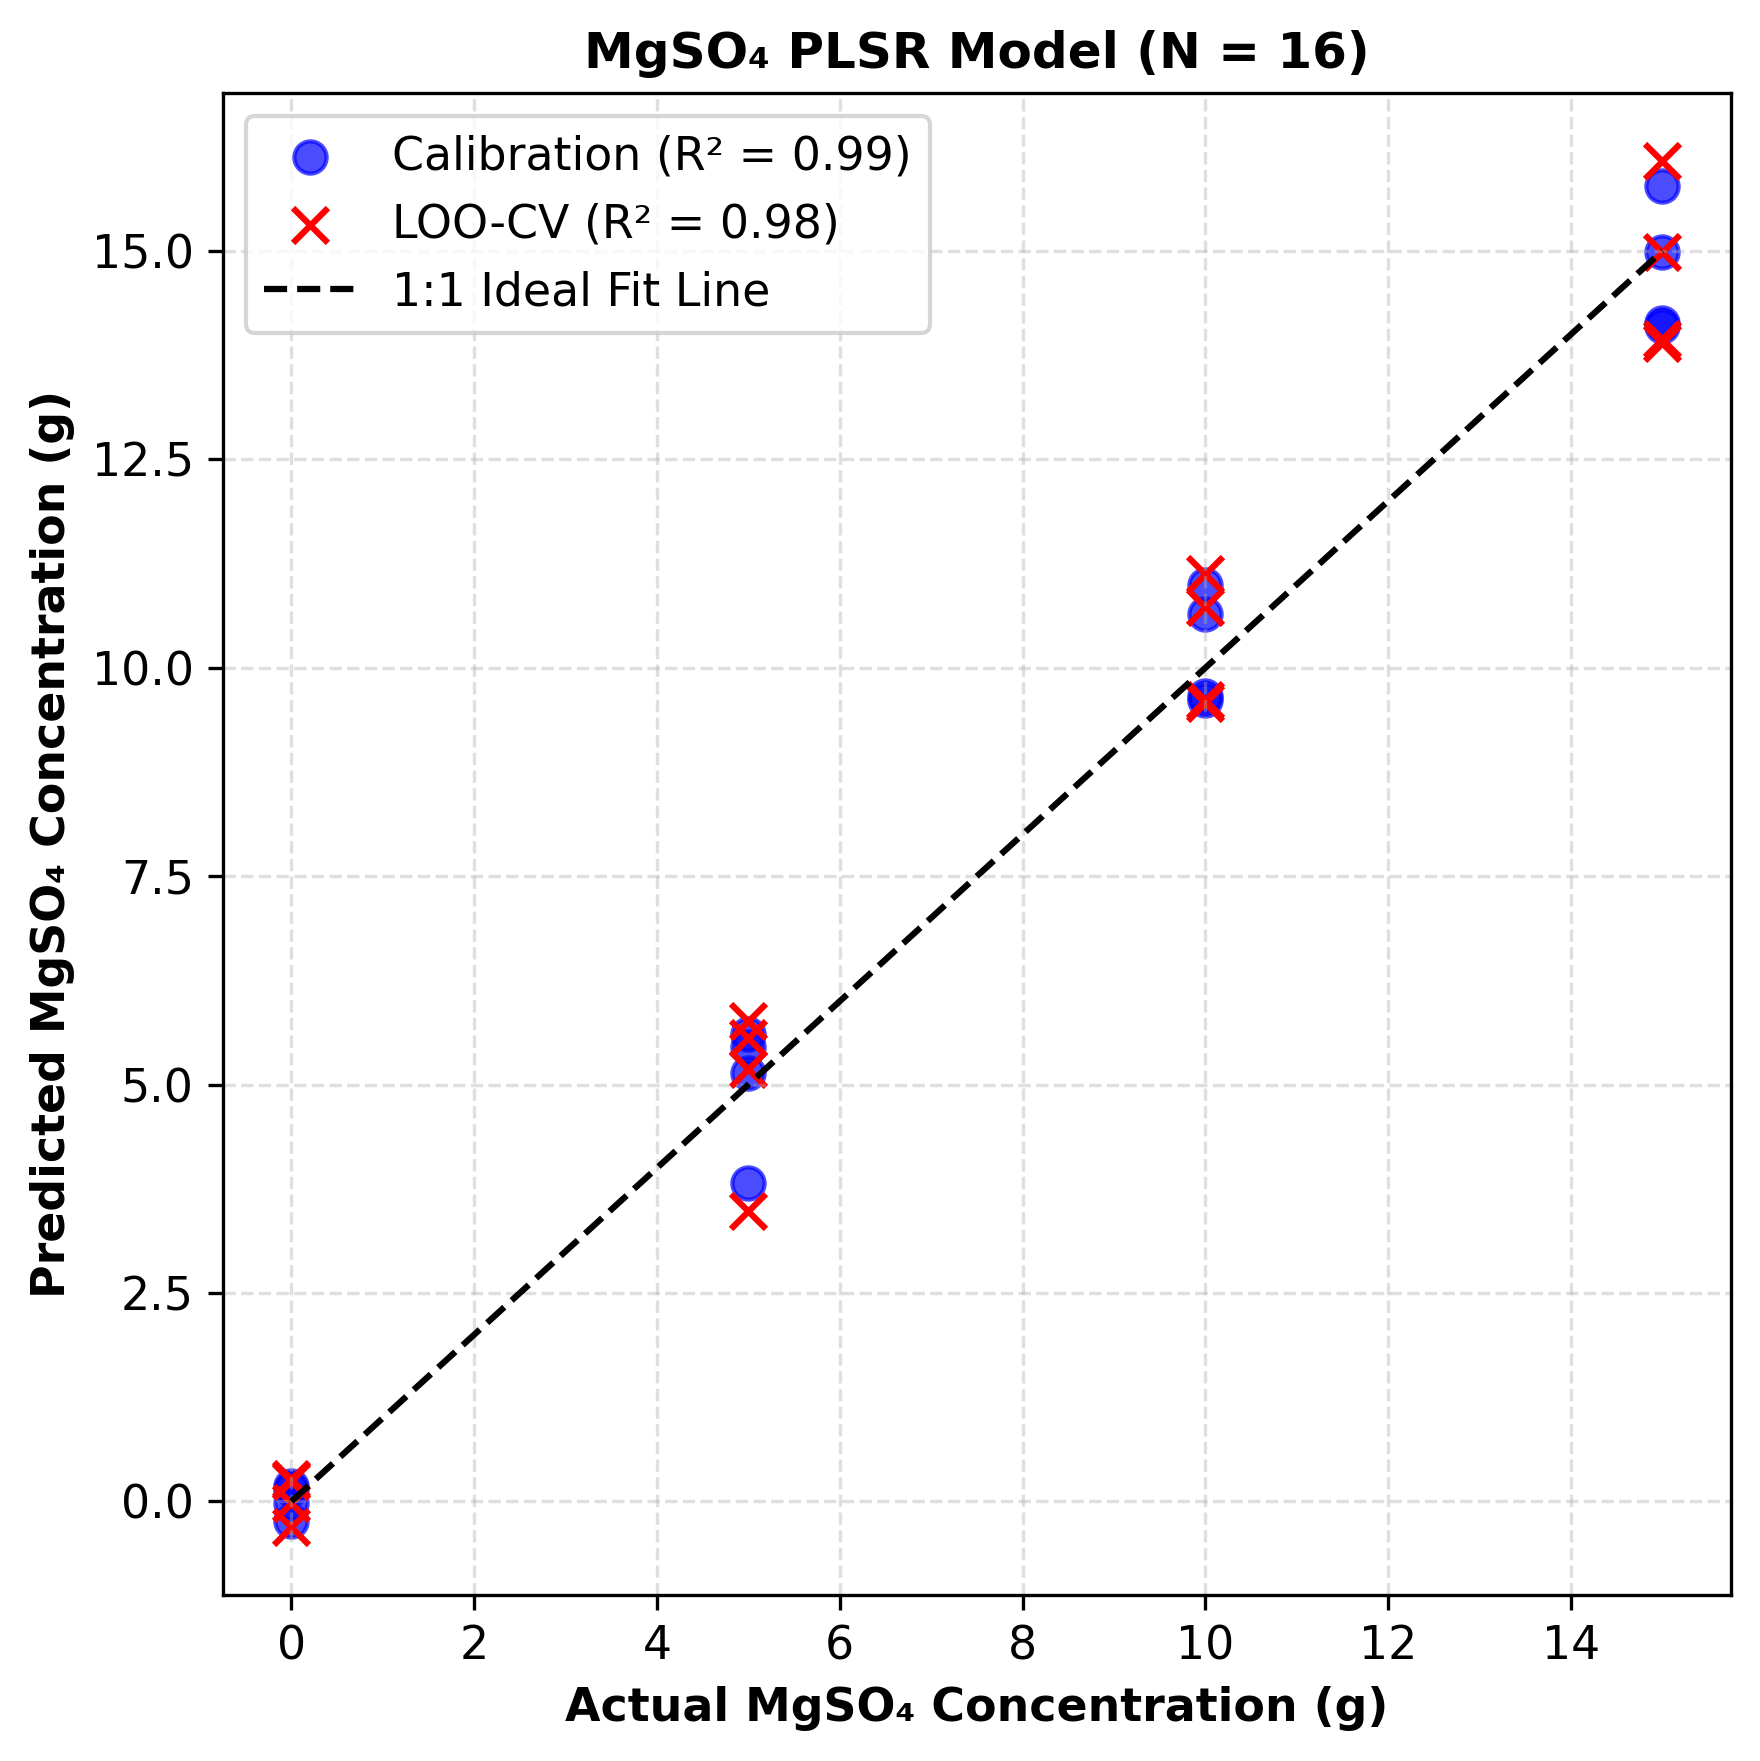

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

def apply_snv(X_data):
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

# ==========================================
# 1. LOAD ALL 16 MgSO4 FILES (NO FILTERING)
# ==========================================
DATA_FOLDER = "."  # Path to MgSO4 text files
file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    # Map target MgSO4 concentrations
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            continue
    
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    mask = (wl >= 1100) & (wl <= 2100)
    if wavelengths is None:
        wavelengths = wl[mask]
        
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

print(f"Successfully loaded ALL {len(y)} MgSO4 files across all rotational angles.")

# ==========================================
# 2. PREPROCESSING & PLSR MODEL (N = 16)
# ==========================================
X_sg = np.array([savgol_filter(spec, window_length=15, polyorder=2) for spec in X_raw])
X = apply_snv(X_sg)

n_components = 2
pls = PLSRegression(n_components=n_components)

pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

loo = LeaveOneOut()
y_cv = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

# ==========================================
# 3. DIAGNOSTIC PRINT: CHECK 0_ANG ERRORS
# ==========================================
print("\n" + "="*50)
print(f"MgSO4 PLSR PERFORMANCE METRICS (N = {len(y)})")
print("="*50)
print(f"Calibration R²   (R²_cal)  : {r2_cal:.4f}")
print(f"Calibration RMSE (RMSEC)   : {rmsec:.4f} g")
print(f"Validation R²    (R²_cv)   : {r2_cv:.4f}")
print(f"Validation RMSE  (RMSECV)  : {rmsecv:.4f} g")
print("="*50)

print("\nIndividual Sample Validation Errors:")
print(f"{'Filename':<32} | {'Actual':<7} | {'Predicted':<9} | {'Error':<7}")
print("-" * 65)

for fname, actual, pred in zip(filenames, y, y_cv):
    err = abs(actual - pred)
    flag = " <--- HIGH ERROR" if err > 3.0 else ""
    print(f"{fname:<32} | {actual:>5.1f} g | {pred:>7.2f} g | {err:>5.2f} g{flag}")

# Scatter Plot
plt.figure(figsize=(6, 6), dpi=300)
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R² = {r2_cal:.2f})', alpha=0.7, s=60)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R² = {r2_cv:.2f})', s=70)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Ideal Fit Line')
plt.xlabel("Actual MgSO₄ Concentration (g)", fontweight='bold')
plt.ylabel("Predicted MgSO₄ Concentration (g)", fontweight='bold')
plt.title(f"MgSO₄ PLSR Model (N = {len(y)})", fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

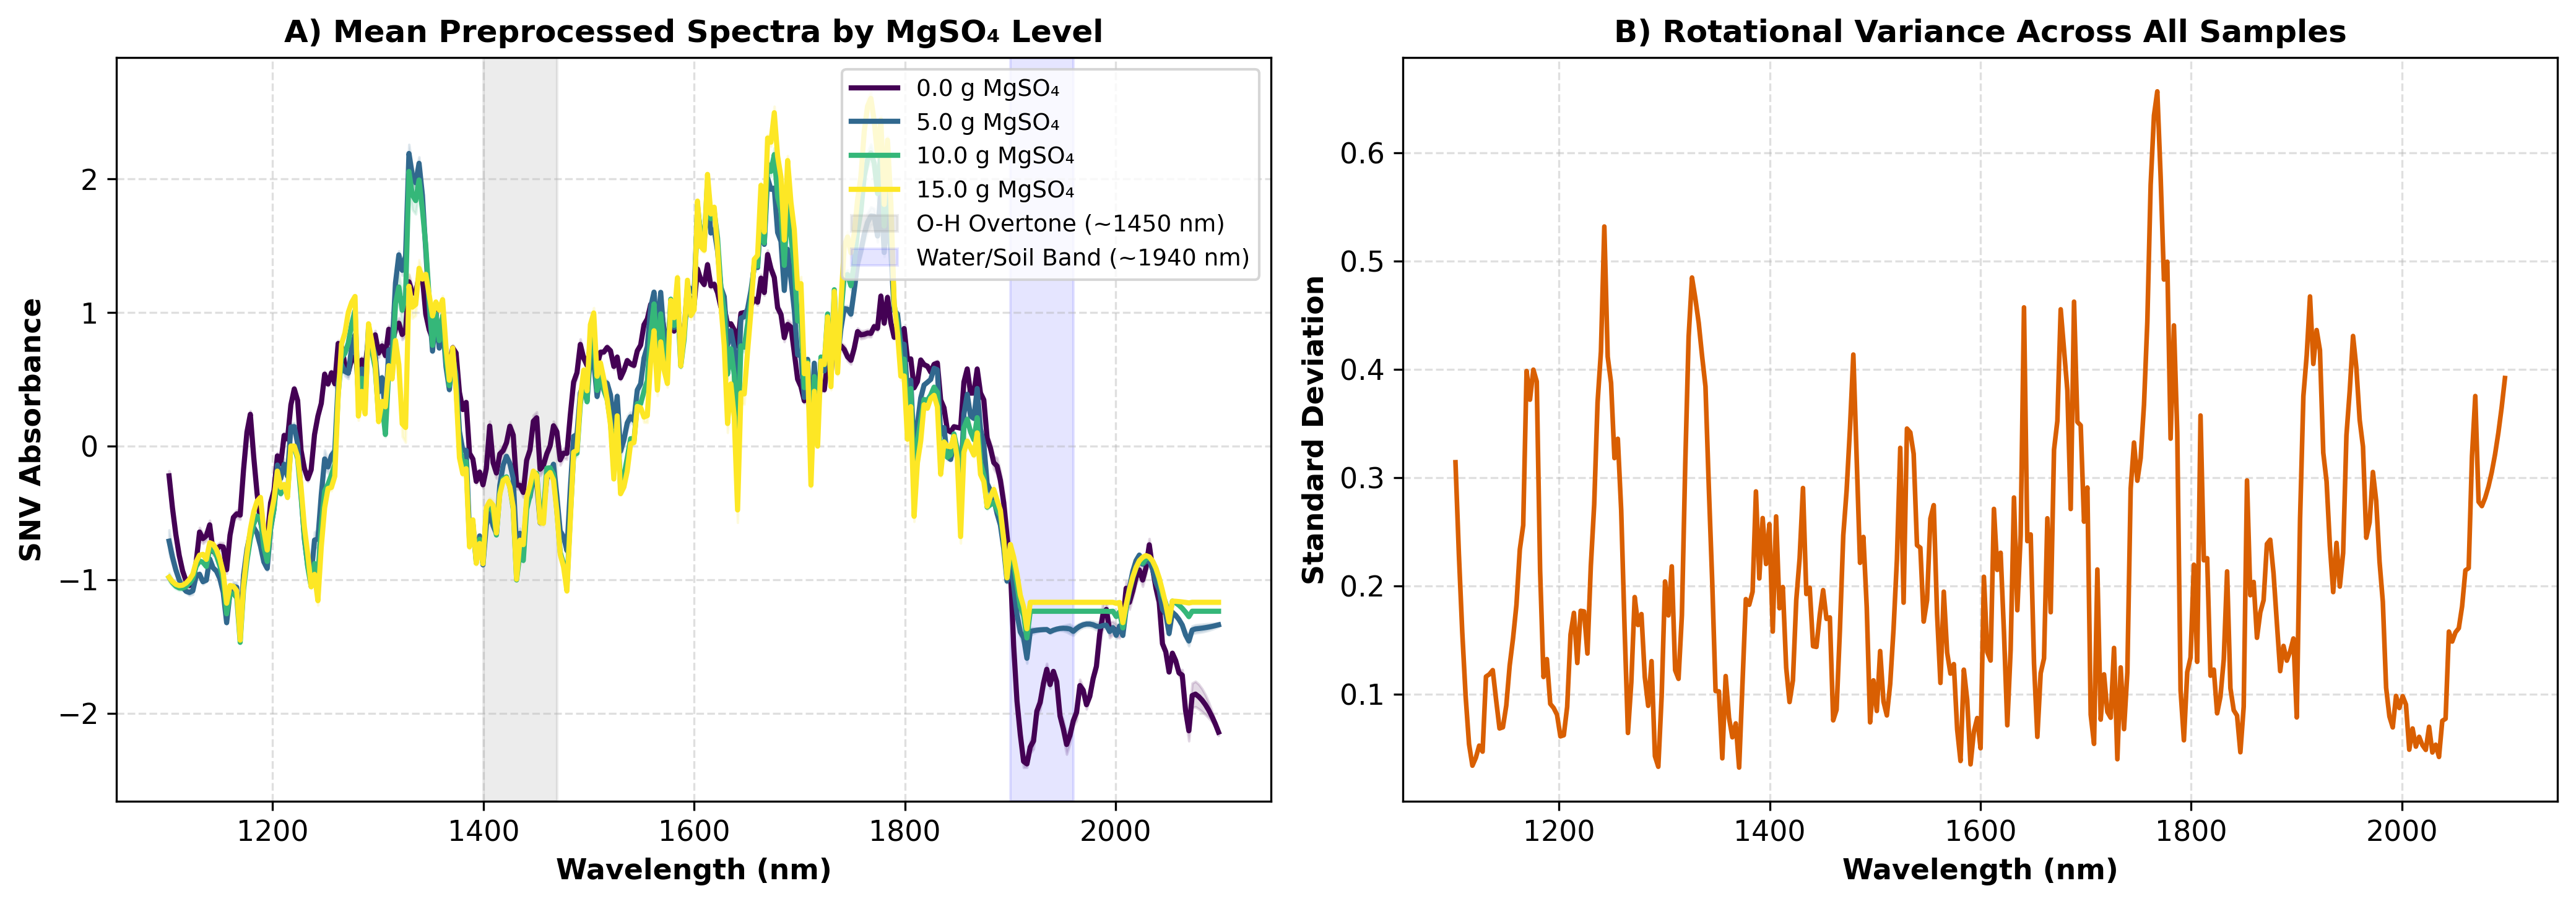

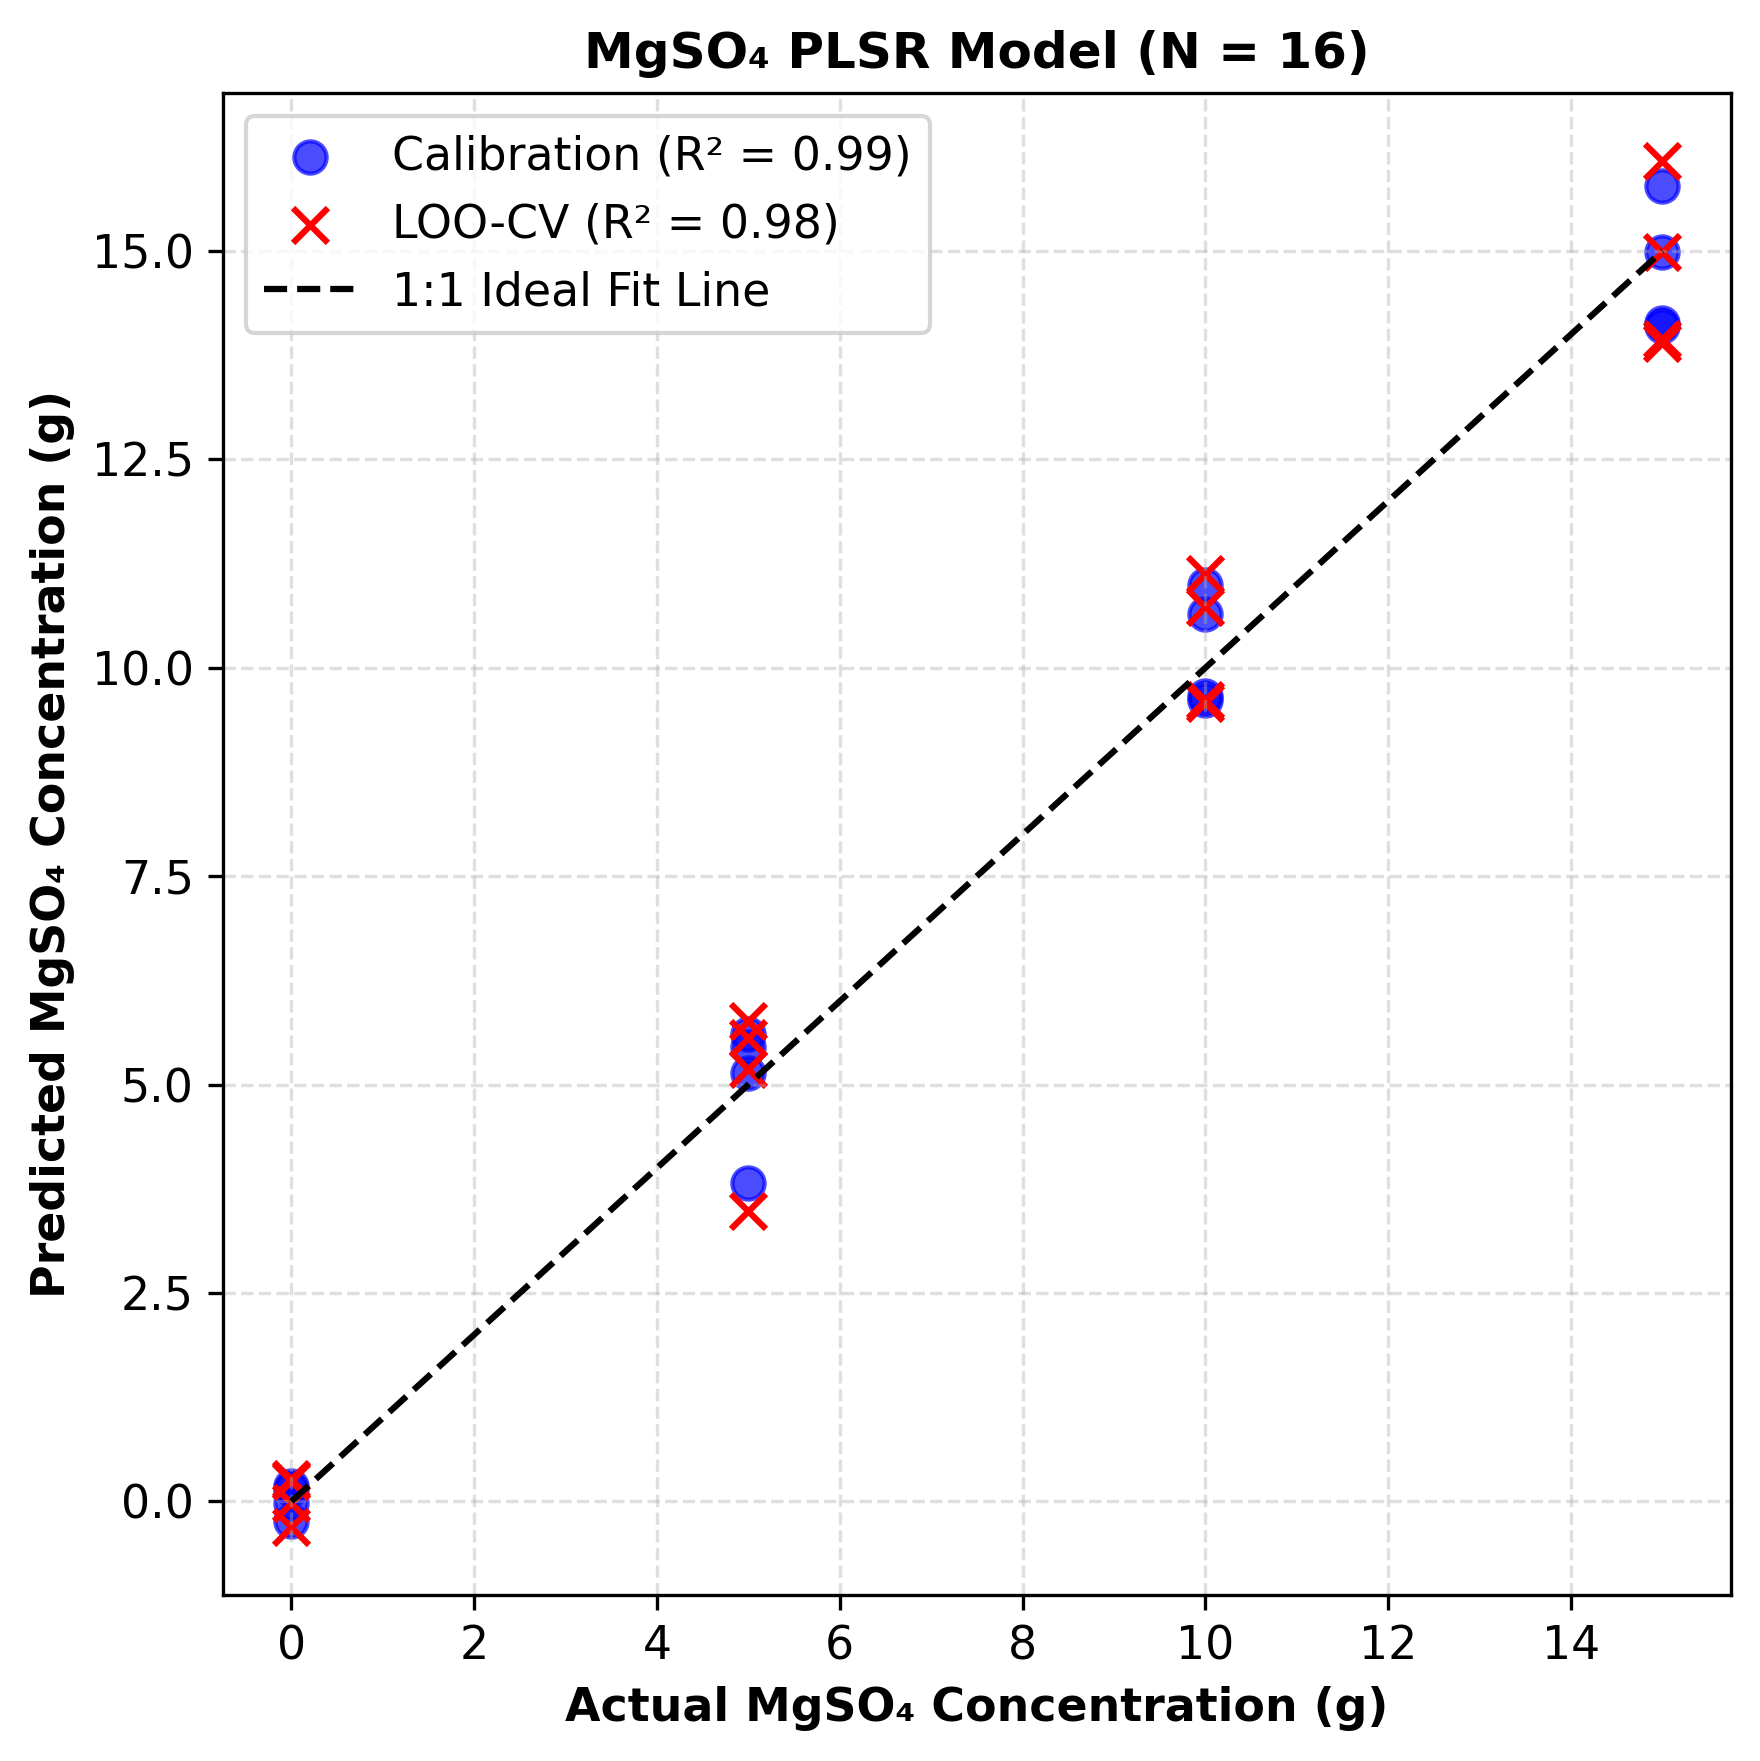

In [3]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# ==========================================
# 1. PREPROCESSING HELPER FUNCTIONS
# ==========================================
def apply_snv(X_data):
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

# ==========================================
# 2. DATA LOADING PIPELINE (N = 16)
# ==========================================
DATA_FOLDER = "."
file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            continue
    
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    mask = (wl >= 1100) & (wl <= 2100)
    if wavelengths is None:
        wavelengths = wl[mask]
        
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

# ==========================================
# 3. SPECTRAL PREPROCESSING (SG + SNV)
# ==========================================
X_sg = np.array([savgol_filter(spec, window_length=15, polyorder=2) for spec in X_raw])
X = apply_snv(X_sg)

# ==========================================
# 4. SUPERVISOR-READY SPECTRAL PLOTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
unique_levels = sorted(list(set(y)))
colors = ['#440154', '#31688e', '#35b779', '#fde725']

for idx, level in enumerate(unique_levels):
    mask = (y == level)
    mean_spec = np.mean(X[mask], axis=0)
    std_spec = np.std(X[mask], axis=0)
    
    ax1.plot(wavelengths, mean_spec, label=f"{level:.1f} g MgSO₄", color=colors[idx], linewidth=2.0)
    ax1.fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec, color=colors[idx], alpha=0.15)

ax1.axvspan(1400, 1470, color='gray', alpha=0.15, label='O-H Overtone (~1450 nm)')
ax1.axvspan(1900, 1960, color='blue', alpha=0.10, label='Water/Soil Band (~1940 nm)')
ax1.set_xlabel("Wavelength (nm)", fontweight='bold')
ax1.set_ylabel("SNV Absorbance", fontweight='bold')
ax1.set_title("A) Mean Preprocessed Spectra by MgSO₄ Level", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

overall_std = np.std(X, axis=0)
ax2.plot(wavelengths, overall_std, color='#d95f02', linewidth=1.8)
ax2.set_xlabel("Wavelength (nm)", fontweight='bold')
ax2.set_ylabel("Standard Deviation", fontweight='bold')
ax2.set_title("B) Rotational Variance Across All Samples", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("MgSO4_NIR_Spectra_Publication.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. PLS REGRESSION & LOO CROSS-VALIDATION
# ==========================================
n_components = 2
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

loo = LeaveOneOut()
y_cv = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

# ==========================================
# 6. SCATTER PLOT
# ==========================================
plt.figure(figsize=(6, 6), dpi=300)
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R² = {r2_cal:.2f})', alpha=0.7, s=60)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R² = {r2_cv:.2f})', s=70)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Ideal Fit Line')

plt.xlabel("Actual MgSO₄ Concentration (g)", fontweight='bold')
plt.ylabel("Predicted MgSO₄ Concentration (g)", fontweight='bold')
plt.title(f"MgSO₄ PLSR Model (N = {len(y)})", fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("MgSO4_PLSR_Regression_Clean.png", dpi=300, bbox_inches='tight')
plt.show()